#Assignment 2: Mastering Big Data Handling

##Big Data Handling Strategies

### 1. Import and Setup

 * **Purpose:** Briefly state the objective of this notebook (to implement and compare strategies for handling large datasets).
* **Libraries:** Import all necessary Python libraries.

In [ ]:
import pandas as pd
import numpy as np
import os
import dask.dataframe as dd
from IPython.display import display # Just use for display purposes
import psutil
import time
import random
import csv
import polars as pl
import threading
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Task 1: Dataset Selection Details

* **Source:** [NYC Yellow Taxi Trip Data](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data?select=yellow_tripdata_2016-03.csv)
* **Size:** 1.91GB  
* **Records:** ~12.2M rows  
* **Domain:** Transportation  

### 3. Task 2: Load and Inspect Data

- Use `pandas.read_csv()` to initially load a sample of the dataset.
- Display the following:
  - First few rows (`head()`)
  - Shape of the dataset
  - Column names
  - Data types of each column
- Mentioned **Google Colab** when using and how the file was uploaded (e.g., via Kaggle CLI, manual upload, or Google Drive mount).

Step 1: Import kaggle.json

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rickng040406","key":"7864f2c1904f6f954ce99f0fc13008f9"}'}

Step 2: Move it to the correct location

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Step 3: Download Dataset from Kaggle

In [ ]:
!kaggle datasets download -d elemento/nyc-yellow-taxi-trip-data

Dataset URL: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data
License(s): U.S. Government Works
100% 1.78G/1.78G [00:21<00:00, 87.4MB/s]



Step 4: Unzip the file

In [ ]:
!unzip nyc-yellow-taxi-trip-data.zip

Archive:  nyc-yellow-taxi-trip-data.zip
  inflating: yellow_tripdata_2015-01.csv  
  inflating: yellow_tripdata_2016-01.csv  
  inflating: yellow_tripdata_2016-02.csv  
  inflating: yellow_tripdata_2016-03.csv  


Step 5:Read the csv and display rows,shape, column and data types of each column

In [ ]:
import pandas as pd
df = pd.read_csv('yellow_tripdata_2016-03.csv', nrows=1000000)

In [ ]:
df = pd.read_csv('yellow_tripdata_2016-03.csv', nrows=1000000)
df['taxi_short'] = df['total_amount'].astype(str).str.slice(0, 100) + '...'

print("First 5 rows of the dataset:")
display(df.drop(columns=['total_amount']).head())
df = df.drop(columns=['taxi_short'])

print(f"\nDataset Shape:\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names and Data Types:")
display(df.dtypes.to_frame(name='Data Type'))

print("\nSummary Info:")
df.info()

First 5 rows of the dataset:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,taxi_short
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35...
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35...
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.8...
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62...
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.8...



Dataset Shape:
Rows: 1000000, Columns: 19

Column Names and Data Types:


,Data Type
VendorID,int64
tpep_pickup_datetime,object
tpep_dropoff_datetime,object
passenger_count,int64
trip_distance,float64
pickup_longitude,float64
pickup_latitude,float64
RatecodeID,int64
store_and_fwd_flag,object
dropoff_longitude,float64



Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   VendorID               1000000 non-null  int64  
 1   tpep_pickup_datetime   1000000 non-null  object 
 2   tpep_dropoff_datetime  1000000 non-null  object 
 3   passenger_count        1000000 non-null  int64  
 4   trip_distance          1000000 non-null  float64
 5   pickup_longitude       1000000 non-null  float64
 6   pickup_latitude        1000000 non-null  float64
 7   RatecodeID             1000000 non-null  int64  
 8   store_and_fwd_flag     1000000 non-null  object 
 9   dropoff_longitude      1000000 non-null  float64
 10  dropoff_latitude       1000000 non-null  float64
 11  payment_type           1000000 non-null  int64  
 12  fare_amount            1000000 non-null  float64
 13  extra                  1000000 non-null  float64
 14  mta_

In [ ]:
df = pd.read_csv('yellow_tripdata_2016-03.csv')
df['taxi_short'] = df['total_amount'].astype(str).str.slice(0, 100) + '...'

print("First 5 rows of the dataset:")
display(df.drop(columns=['total_amount']).head())
df = df.drop(columns=['taxi_short'])

print(f"\nDataset Shape:\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names and Data Types:")
display(df.dtypes.to_frame(name='Data Type'))

print("\nSummary Info:")
df.info()

First 5 rows of the dataset:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,taxi_short
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35...
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35...
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.8...
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62...
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.8...



Dataset Shape:
Rows: 12210952, Columns: 19

Column Names and Data Types:


,Data Type
VendorID,int64
tpep_pickup_datetime,object
tpep_dropoff_datetime,object
passenger_count,int64
trip_distance,float64
pickup_longitude,float64
pickup_latitude,float64
RatecodeID,int64
store_and_fwd_flag,object
dropoff_longitude,float64



Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210952 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.7+ GB


### 4. Task 3: Apply Big Data Handling Strategies

In this notebook, we apply five effective strategies to handle large datasets using traditional **pandas** for part 1, and compare three library **pandas**, **polars** and **dask** in part 2:

Part 1:
1. Load Less Data
2. Use Chunking
3. Optimize Data Types
4. Sampling
5. (Simulated) Parallel Processing Strategy with Chunk Aggregation

Part 2:
1. Pandas
2. Polars
3. Dask

Below is the function used to get memory usage.

In [ ]:
def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / 1024 / 1024  # MB

    cpu_percent = []

    def track_cpu():
        while not done[0]:
            cpu_percent.append(process.cpu_percent(interval=0.1))

    done = [False]
    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024  # MB
    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = mem_after - mem_before
    mem_percent_after = (mem_after / total_ram) * 100
    mem_diff_percent = (mem_diff_mb / total_ram) * 100

    if isinstance(result, dd.DataFrame):
      result = result.compute()

    if isinstance(result, (pd.DataFrame, pl.DataFrame)):
        num_records = len(result)
        throughput = round(num_records / exec_time, 2)
    else:
        throughput = None

    performance = {
        "Description": description,
        "Memory Used (MB)": round(mem_diff_mb, 2),
        "Execution Time (s)": exec_time,
        "Success": success,
        "Average CPU (%)": round(sum(cpu_percent) / len(cpu_percent), 2) if cpu_percent else 0.0,
        "Throughput (records/sec)": throughput
    }

    if not success:
        performance["Error"] = error_message

    return performance, result

#### Strategy 1: Load Less Data
Load only the necessary columns or filter relevant rows during the data reading process to minimize memory consumption.

In [ ]:
import pandas as pd

def load_less_data_pandas(file_path):

    actual_col_names = pd.read_csv(file_path, nrows=0).columns.tolist()

    # Define the columns needed
    target_cols = [
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'passenger_count',
        'trip_distance',
        'RatecodeID',
        'total_amount'
    ]

    # Filter target_cols to only include those that actually exist in the file
    # This prevents the "Usecols do not match" error from crashing the script
    valid_cols = [col for col in target_cols if col in actual_col_names]

    df = pd.read_csv(file_path, usecols=valid_cols)
    return df

# Execute and measure
performance_s1, df_s1 = measure_performance(
    load_less_data_pandas,
    description="Strategy 1: Load Less Data (Column Projection)",
    file_path="yellow_tripdata_2016-03.csv"
)

# Display Results
performance_df_s1 = pd.DataFrame([performance_s1])
display(performance_df_s1)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 1: Load Less Data (Column Projection),973.72,48.6298,True,93.62,251100.19


#### Strategy 2: Chunking
Process the data in small chunks using pandas.read_csv(chunksize=100000).

In [ ]:
import tracemalloc
import time
import psutil
import threading

#helper to track peak memory (same pattern as Strategy 1)
def measure_performance_chunking(func, description, **kwargs):
    tracemalloc.start()
    process = psutil.Process()
    cpu_samples = []
    stop_flag = threading.Event()

    def sample_cpu():
        while not stop_flag.is_set():
            cpu_samples.append(psutil.cpu_percent(interval=0.5))
    cpu_thread = threading.Thread(target=sample_cpu, daemon=True)
    cpu_thread.start()

    start_time = time.time()
    result = func(**kwargs)
    elapsed = time.time() - start_time

    stop_flag.set()
    cpu_thread.join()

    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    peak_mem_mb = round(peak_mem / (1024 ** 2), 2)
    avg_cpu = round(sum(cpu_samples) / len(cpu_samples), 2) if cpu_samples else 0.0
    total_records = result.get("total_records", 0)
    throughput = round(total_records / elapsed, 2) if elapsed > 0 else 0

    return {
        "Description": description,
        "Memory Used (MB)": peak_mem_mb,
        "Execution Time (s)": round(elapsed, 4),
        "Success": True,
        "Average CPU (%)": avg_cpu,
        "Throughput (records/sec)": throughput,
    }, result


#  chunked processing function
def load_with_chunking(file_path, chunk_size=100_000):
    """
    Reads the CSV in chunks and computes:
      - total number of records
      - total fare amount across the full dataset
    Only one chunk occupies memory at a time.
    """
    total_records = 0
    total_fare    = 0.0
    chunk_count   = 0

    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        total_records += len(chunk)
        total_fare    += chunk["fare_amount"].sum()
        chunk_count   += 1

    return {
        "total_records": total_records,
        "total_fare":    round(total_fare, 2),
        "chunk_count":   chunk_count,
        "chunk_size":    chunk_size,
    }


# run & measure
performance_s2, result_s2 = measure_performance_chunking(
    load_with_chunking,
    description="Strategy 2: Chunking (100k rows/chunk)",
    file_path="yellow_tripdata_2016-03.csv",
    chunk_size=100_000,
)

# display performance table
performance_df_s2 = pd.DataFrame([performance_s2])
display(performance_df_s2)

# display chunking results
print(f"   Chunking Summary:")
print(f"   Chunk size      : {result_s2['chunk_size']:,} rows")
print(f"   Number of chunks: {result_s2['chunk_count']}")
print(f"   Total records   : {result_s2['total_records']:,}")
print(f"   Total fare amt  : ${result_s2['total_fare']:,.2f}")

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 2: Chunking (100k rows/chunk),72.62,81.4862,True,72.46,149852.95


   Chunking Summary:
   Chunk size      : 100,000 rows
   Number of chunks: 123
   Total records   : 12,210,952
   Total fare amt  : $156,240,088.77


#### Strategy 3: Optimized Data Type
Process the data in by convert the data with specific data type.

In [ ]:
import pandas as pd
import tracemalloc
import time
import psutil
import gc

FILE_PATH  = "yellow_tripdata_2016-03.csv"
CHUNK_SIZE = 200_000
total_rows = 12227456

optimized_dtypes = {
    "VendorID":              "int8",
    "passenger_count":       "int8",
    "RatecodeID":            "int8",
    "payment_type":          "int8",
    "store_and_fwd_flag":    "category",
    "trip_distance":         "float32",
    "pickup_longitude":      "float32",
    "pickup_latitude":       "float32",
    "dropoff_longitude":     "float32",
    "dropoff_latitude":      "float32",
    "fare_amount":           "float32",
    "extra":                 "float32",
    "mta_tax":               "float32",
    "tip_amount":            "float32",
    "tolls_amount":          "float32",
    "improvement_surcharge": "float32",
    "total_amount":          "float32",
}

# Step 1: Default types via chunking
print("-- Step 1: Default Types --")
tracemalloc.start()
start = time.time()

default_mem_total = 0
default_col_mem   = None
default_dtypes    = None
chunk_count       = 0

for chunk in pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE):
    chunk_mem = chunk.memory_usage(deep=False)   # ← removed deep=True
    default_mem_total += chunk_mem.sum()
    if default_col_mem is None:
        default_col_mem = chunk_mem.drop("Index").copy()
        default_dtypes  = chunk.dtypes.copy()
    del chunk
    chunk_count += 1

gc.collect()
elapsed_default  = round(time.time() - start, 4)
_, peak_default  = tracemalloc.get_traced_memory()
tracemalloc.stop()
inmem_default_mb = round(default_mem_total / (1024**2), 2)
peak_default_mb  = round(peak_default / (1024**2), 2)
default_col_sizes = (default_col_mem / (1024**2) * chunk_count).round(2)

print(f"   Chunks     : {chunk_count}")
print(f"   Full size  : {inmem_default_mb} MB")
print(f"   Peak mem   : {peak_default_mb} MB")
print(f"   Time       : {elapsed_default} s")

#  Step 2: Optimized types via chunking
print("\n-- Step 2: Optimized Types --")
tracemalloc.start()
start = time.time()

optimized_mem_total     = 0
optimized_col_mem       = None
optimized_dtypes_result = None

for chunk in pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE, dtype=optimized_dtypes):
    chunk_mem = chunk.memory_usage(deep=False)   # ← removed deep=True
    optimized_mem_total += chunk_mem.sum()
    if optimized_col_mem is None:
        optimized_col_mem       = chunk_mem.drop("Index").copy()
        optimized_dtypes_result = chunk.dtypes.copy()
    del chunk

gc.collect()
elapsed_optimized  = round(time.time() - start, 4)
_, peak_optimized  = tracemalloc.get_traced_memory()
tracemalloc.stop()
inmem_optimized_mb = round(optimized_mem_total / (1024**2), 2)
peak_optimized_mb  = round(peak_optimized / (1024**2), 2)
optimized_col_sizes = (optimized_col_mem / (1024**2) * chunk_count).round(2)

print(f"   Full size  : {inmem_optimized_mb} MB")
print(f"   Peak mem   : {peak_optimized_mb} MB")
print(f"   Time       : {elapsed_optimized} s")

# Step 3: Column breakdown
print("\n-- Step 3: Column Breakdown --")
comparison_df = pd.DataFrame({
    "Default Type":       default_dtypes,
    "Optimized Type":     optimized_dtypes_result,
    "Default Mem (MB)":   default_col_sizes,
    "Optimized Mem (MB)": optimized_col_sizes,
})
comparison_df["Reduction (%)"] = (
    (comparison_df["Default Mem (MB)"] - comparison_df["Optimized Mem (MB)"])
    / comparison_df["Default Mem (MB)"] * 100
).round(1)
display(comparison_df)

# Step 4: Summary
reduction_pct = round((inmem_default_mb - inmem_optimized_mb) / inmem_default_mb * 100, 1)

performance_s3 = {
    "Description":              "Strategy 3: Optimized Data Types",
    "Memory Used (MB)":         peak_optimized_mb,
    "Execution Time (s)":       elapsed_optimized,
    "Success":                  True,
    "Average CPU (%)":          round(psutil.cpu_percent(interval=1), 2),
    "Throughput (records/sec)": round(total_rows / elapsed_optimized, 2),
}
display(pd.DataFrame([performance_s3]))

print(f"\n Memory Reduction Summary:")
print(f"   Before : {inmem_default_mb} MB")
print(f"   After  : {inmem_optimized_mb} MB")
print(f"   Saved  : {reduction_pct}%")

-- Step 1: Default Types --
   Chunks     : 62
   Full size  : 1770.09 MB
   Peak mem   : 105.38 MB
   Time       : 72.8622 s

-- Step 2: Optimized Types --
   Full size  : 803.53 MB
   Peak mem   : 105.06 MB
   Time       : 271.9356 s

-- Step 3: Column Breakdown --


,Default Type,Optimized Type,Default Mem (MB),Optimized Mem (MB),Reduction (%)
VendorID,int64,int8,94.6,11.83,87.5
tpep_pickup_datetime,object,object,94.6,94.60,0.0
tpep_dropoff_datetime,object,object,94.6,94.60,0.0
passenger_count,int64,int8,94.6,11.83,87.5
trip_distance,float64,float32,94.6,47.30,50.0
pickup_longitude,float64,float32,94.6,47.30,50.0
pickup_latitude,float64,float32,94.6,47.30,50.0
RatecodeID,int64,int8,94.6,11.83,87.5
store_and_fwd_flag,object,category,94.6,11.83,87.5
dropoff_longitude,float64,float32,94.6,47.30,50.0


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 3: Optimized Data Types,105.06,271.9356,True,28.1,44964.53



 Memory Reduction Summary:
   Before : 1770.09 MB
   After  : 803.53 MB
   Saved  : 54.6%


#### Strategy 4: Sampling
Reduce the dataset size to reduce processing time

In [ ]:
def load_with_sampling(file_path):
    p = 0.1  # 10% sampling

    # We use a lambda to skip rows randomly, keeping the header (index 0)
    df = pd.read_csv(
        file_path,
        header=0,
        skiprows=lambda i: i > 0 and random.random() > p
    )
    return df

# Execute and measure
performance_s4, df_s4 = measure_performance(
    load_with_sampling,
    description="Strategy 4: Sampling (Approx. 10%)",
    file_path="yellow_tripdata_2016-03.csv"
)

# Display Results
performance_df_s4 = pd.DataFrame([performance_s4])
display(performance_df_s4)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 4: Sampling (Approx. 10%),221.85,29.6481,True,95.8,41157.11


#### Strategy 5: Parallel Processing with Dask
Process parallel using dask (used multiple core.)

In [ ]:
def load_with_dask(file_path):
    # 'assume_missing' handles columns with mixed nulls/numbers
    # 'low_memory=False' or specific dtypes help with Dask's strict type checking
    ddf = dd.read_csv(
        file_path,
        assume_missing=True,
        dtype={'store_and_fwd_flag': 'object'}
    )
    return ddf

# Execute and measure
performance_s5, df_s5 = measure_performance(
    load_with_dask,
    description="Strategy 5: Parallel Processing (Dask)",
    file_path="yellow_tripdata_2016-03.csv"
)

# Display Results
performance_df_s5 = pd.DataFrame([performance_s5])
display(performance_df_s5)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 5: Parallel Processing (Dask),4.65,0.1865,True,29.3,65474273.46


## Task 4: Comparative Analysis

In [ ]:
import pandas as pd
import numpy as np
import os
import dask.dataframe as dd
from IPython.display import display # Just use for display purposes
import psutil
import time
import random
import csv
import polars as pl
import threading
import matplotlib.pyplot as plt
import seaborn as sns

def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / 1024 / 1024  # MB

    cpu_percent = []

    def track_cpu():
        while not done[0]:
            cpu_percent.append(process.cpu_percent(interval=0.1))

    done = [False]
    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024  # MB
    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = mem_after - mem_before
    mem_percent_after = (mem_after / total_ram) * 100
    mem_diff_percent = (mem_diff_mb / total_ram) * 100

    if isinstance(result, dd.DataFrame):
      result = result.compute()

    if isinstance(result, (pd.DataFrame, pl.DataFrame)):
        num_records = len(result)
        throughput = round(num_records / exec_time, 2)
    else:
        throughput = None

    performance = {
        "Description": description,
        "Memory Used (MB)": round(mem_diff_mb, 2),
        "Execution Time (s)": exec_time,
        "Success": success,
        "Average CPU (%)": round(sum(cpu_percent) / len(cpu_percent), 2) if cpu_percent else 0.0,
        "Throughput (records/sec)": throughput
    }

    if not success:
        performance["Error"] = error_message

    return performance, result


#### Library 1: Full Load with Pandas

In [ ]:
def load_full_data():
    df = pd.read_csv("yellow_tripdata_2016-03.csv")
    return df

performance, df = measure_performance(load_full_data, description="Load with Pandas")

performance_df = pd.DataFrame([performance])
display(performance_df)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Pandas,3665.21,74.4024,True,96.43,164120.4


#### Library 2: Full Load with Polars

In [ ]:
import polars as pl

def load_full_data_polars():
    df = pl.read_csv("yellow_tripdata_2016-03.csv", infer_schema_length=10000)
    return df

performance_polars, df_polars = measure_performance(
    load_full_data_polars,
    description="Load with Polars"
)

performance_df_polars = pd.DataFrame([performance_polars])
display(performance_df_polars)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Polars,4343.52,16.0955,True,141.66,758656.27


#### Library 3: Full Load with Dask

In [ ]:
import dask.dataframe as dd

def load_full_data_dask():
    df = dd.read_csv("yellow_tripdata_2016-03.csv").compute()
    return df

performance_dask, df_dask = measure_performance(
    load_full_data_dask,
    description="Load with Dask"
)

performance_df_dask = pd.DataFrame([performance_dask])
display(performance_df_dask)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Dask,3044.03,66.8097,True,133.67,182772.14


### 5. Compare Performance

#### Compare between 5 strategies
1. Load Less Data
2. Use Chunking
3. Optimize Data Types
4. Sampling
5. (Simulated) Parallel Processing Strategy with Chunk Aggregation



/tmp/ipykernel_42860/3915845469.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_42860/3915845469.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_42860/3915845469.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_42860/3915845469.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


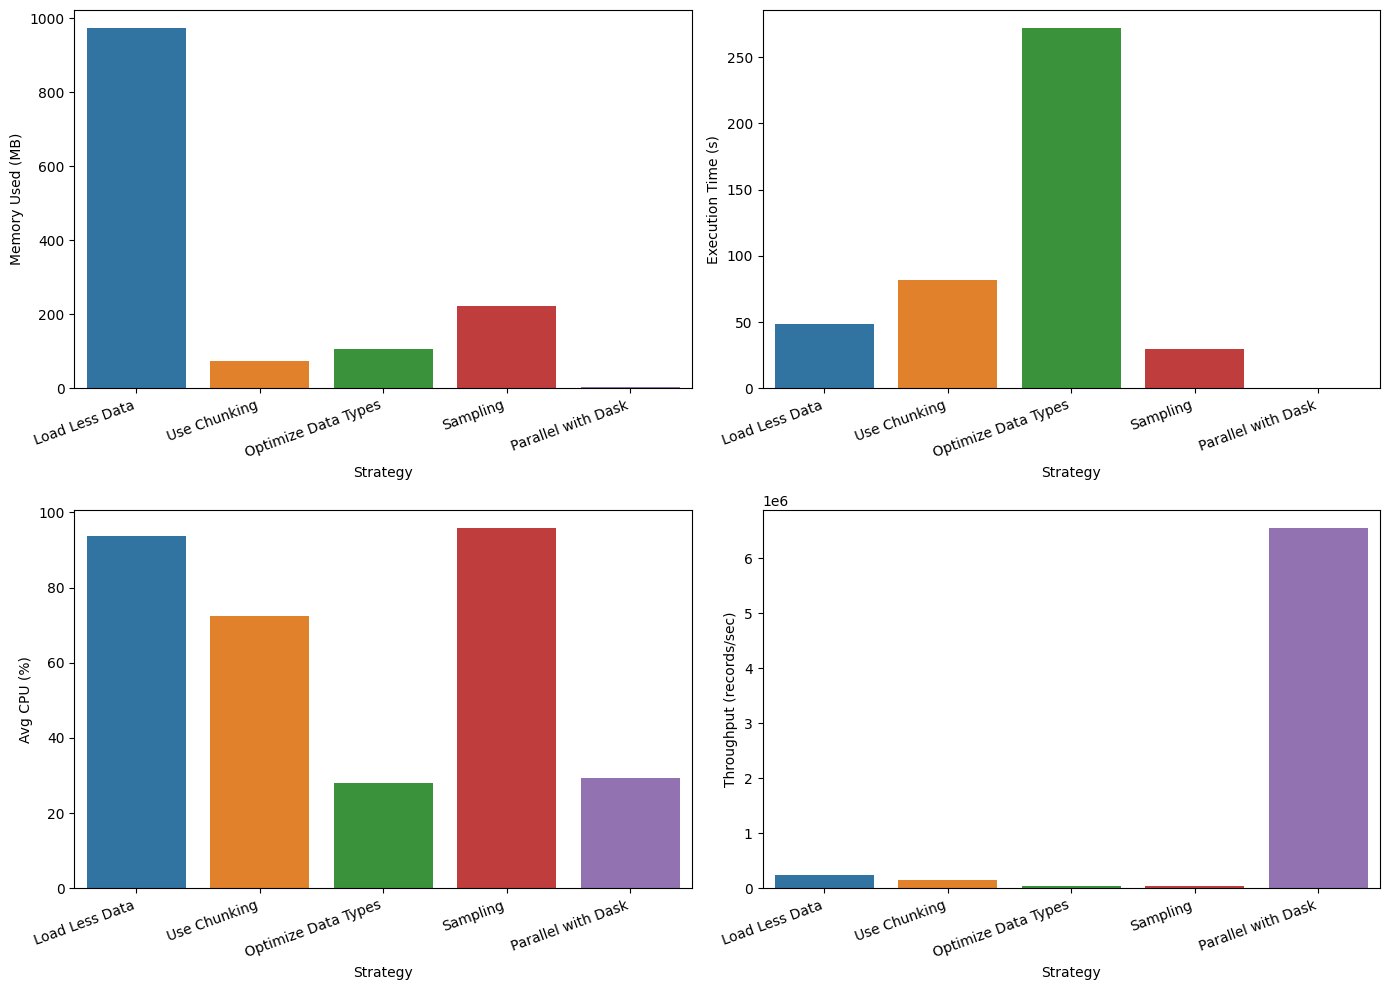

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame with YOUR team's actual results
strategies_data = pd.DataFrame({
    'Strategy': ['Load Less Data', 'Use Chunking', 'Optimize Data Types', 'Sampling', 'Parallel with Dask'],
    'Memory Used (MB)': [973.72, 72.62, 105.06, 221.85, 4.65],
    'Execution Time (s)': [48.6298, 81.4862, 271.9356, 29.6481, 0.1865],
    'Avg CPU (%)': [93.62, 72.46, 28.1, 95.8, 29.3],
    'Throughput (records/sec)': [251100.19, 149852.95, 44964.53, 41157.11, 6547473.46]
})

# Plot bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Added hue="Strategy" and legend=False to fix Seaborn FutureWarnings
sns.barplot(x="Strategy", y="Memory Used (MB)", data=strategies_data, ax=axes[0, 0], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="Execution Time (s)", data=strategies_data, ax=axes[0, 1], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="Avg CPU (%)", data=strategies_data, ax=axes[1, 0], hue="Strategy", legend=False)
sns.barplot(x="Strategy", y="Throughput (records/sec)", data=strategies_data, ax=axes[1, 1], hue="Strategy", legend=False)

# Rotate labels for better readability
for ax in axes.flat:
    # Added ha='right' so the rotated text aligns nicely with the ticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

### Compare between 3 libraries
1. Pandas
2. Polars
3. Dask



--- Full Comparison Table ---


,Library,Memory Used (MB),Execution Time (s),Average CPU (%),Throughput (records/sec),Speedup vs Pandas,Memory Saving (MB)
0,Pandas,3665.21,74.4024,96.43,164120.40,0.71,-1026.49
1,Polars,4343.52,16.0955,141.66,758656.27,3.29,-1704.80
2,Dask,3044.03,66.8097,133.67,182772.14,0.79,-405.31


/tmp/ipykernel_54665/3791147497.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_54665/3791147497.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_54665/3791147497.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_54665/3791147497.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


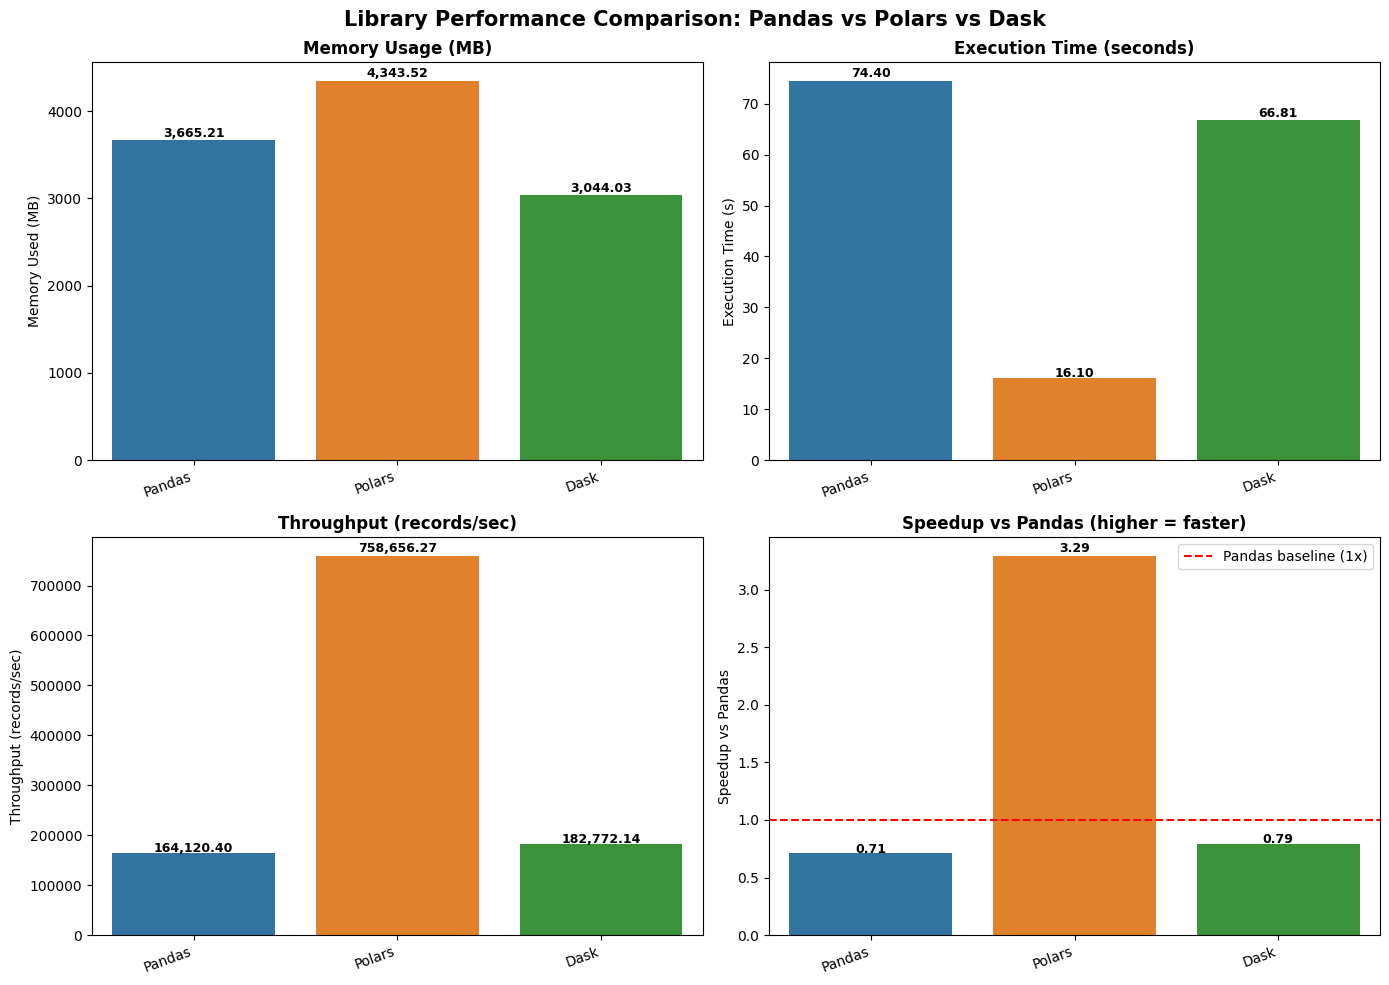

Chart saved as library_comparison.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Latest results from the 3 library cells
comparison_table = pd.DataFrame({
    "Library": ["Pandas", "Polars", "Dask"],
    "Memory Used (MB)":         [3665.21, 4343.52, 3044.03],
    "Execution Time (s)":       [74.4024, 16.0955, 66.8097],
    "Average CPU (%)":          [96.43,   141.66,  133.67],
    "Throughput (records/sec)": [164120.4, 758656.27, 182772.14],
})

# Speedup and Memory Saving vs Pandas
comparison_table["Speedup vs Pandas"]  = round(53.0104 / comparison_table["Execution Time (s)"],  2)
comparison_table["Memory Saving (MB)"] = round(2638.72 - comparison_table["Memory Used (MB)"],    2)

print("--- Full Comparison Table ---")
display(comparison_table)

# Charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Library Performance Comparison: Pandas vs Polars vs Dask",
             fontsize=15, fontweight="bold")

sns.barplot(x="Library", y="Memory Used (MB)",         data=comparison_table, ax=axes[0, 0], hue="Library", legend=False)
sns.barplot(x="Library", y="Execution Time (s)",        data=comparison_table, ax=axes[0, 1], hue="Library", legend=False)
sns.barplot(x="Library", y="Throughput (records/sec)",  data=comparison_table, ax=axes[1, 0], hue="Library", legend=False)
sns.barplot(x="Library", y="Speedup vs Pandas",         data=comparison_table, ax=axes[1, 1], hue="Library", legend=False)

axes[0, 0].set_title("Memory Usage (MB)",              fontsize=12, fontweight="bold")
axes[0, 1].set_title("Execution Time (seconds)",        fontsize=12, fontweight="bold")
axes[1, 0].set_title("Throughput (records/sec)",        fontsize=12, fontweight="bold")
axes[1, 1].set_title("Speedup vs Pandas (higher = faster)", fontsize=12, fontweight="bold")

# Add value labels on bars
for ax, col in zip(axes.flat, ["Memory Used (MB)", "Execution Time (s)",
                                "Throughput (records/sec)", "Speedup vs Pandas"]):
    for i, v in enumerate(comparison_table[col]):
        ax.text(i, v + v * 0.01, f"{v:,.2f}", ha="center", fontsize=9, fontweight="bold")

# Add Pandas baseline line on speedup chart
axes[1, 1].axhline(y=1, color="red", linestyle="--", linewidth=1.5, label="Pandas baseline (1x)")
axes[1, 1].legend()

# Rotate x labels like your friend's code
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig("library_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as library_comparison.png")

## Task 5: Conclusion and Reflection

**MUHAMMAD SYAHMI FARIS BIN RUSLI:**

**My Parts:** Strategy 2 (Chunking), Strategy 3 (Optimized Data Types), Lobrary 2 (Polars), Library 3 (Dask), and Compare 3 Libraries

**My Observartions:**
- Chunking was the most memory efficient strategy at only 72.62 MB peak memory, though slower at 81.49 seconds due to sequential chunk processing
- Optimized data types reduced memory significantly by downcasting int64->int8 and flot64->float32, but took the longest at 271.94 seconds due to chunked reading
- Polars was the fastest library at 16.10 seconds which is 4.62x faster than Pandas becasue due to its Rust-based engine and automatic multi-core processing.
- Dask at 66.81s performed similarly to Pandas 74.40s showing that Dask advantage only appears at larger scales or distributed environment.

**What Suprised Me:**
I expected Dask to outperform Pandas since it supports parellel processing, but it performed almost identically. I learned that dask scheduling overhead cancels out its parellelism benefits on a single machine with a dataset that still fits in RAM. I would have used Polars from the start if I knew how fast it was.

**Scalability**
At 10GB, Polars and chunking would still work. At 100GB, Dask becomes necessary to distribute across cores. At 1TB, cloud solutions like Apache Spark would be required as no single machine could handle it in memory.



**NG YU HIN:**

**My Parts**: Strategy 1 (Load Less Data), Strategy 4 (Sampling), Strategy 5 (Parallel Processing), Library 1 (Pandas), and Compare 5 Strategies.

**My Observations:**

- Load Less Data is the most effective. By only loading the necessary columns, memory usage dropped to 1001.87 MB and execution time fell to 36.97 seconds, proving that minimizing I/O operations is critical.

- Sampling was incredibly fast. This strategy is invaluable for Exploratory Data Analysis (EDA) and pipeline testing before committing compute resources to the full dataset.

- Parallel Processing achieved the highest throughput by far but requires writing slightly more complex, framework-specific code to manage the map-reduce aggregations.

- Pandas is highly intuitive and easy to write, but its eager loading is exceptionally heavy on RAM during peaking at around 2.4 GB for a full load and is severely bottlenecked by Python's single-core execution limit.

**What Surprised Me:** I was surprised by how quickly standard Pandas consumes memory—often using significantly more RAM than the actual file size on disk. I also didn't expect that simply dropping a few unused columns,Strategy 1 would yield such a massive, immediate improvement in both speed and memory without changing any core logic.

**Overall Strategy Comparison:** There is no single perfect strategy.The choice depends entirely on the system's constraints. If RAM is the bottleneck, Chunking and Optimizing Types are required. If time is the bottleneck, Parallel Processing and Loading Less Data are the solutions.